In [1]:
import scanpy as sc
import pandas as pd
import anndata as ad
import squidpy as sq
import stlearn as st

import sopa
import matplotlib.pyplot as plt
from spatialdata._logging import logger
import spatialdata_io as spio
from spatialdata_io.experimental import from_legacy_anndata, to_legacy_anndata
import sopa.io
import spatialdata_plot

In [2]:
import subprocess
from pathlib import Path
system = subprocess.check_output(["hostname", "-s"]).decode("utf-8").strip()
BASE_PATH_ = Path()
if "bun" in system:
    BASE_PATH_ = Path("/QRISdata/Q1851/Xiao/")
elif "imb-quan-gpu" in system:
    BASE_PATH_ = Path("/home/uqxtan9/Q1851/Xiao/")


BASE_PATH = BASE_PATH_ / "Working_project/MB"
DATA_PATH = BASE_PATH / "Xenium_Brain"
XENIUM_RAW_PATH = DATA_PATH / "Xenium_RAW"
MALDI_RAW_PATH = DATA_PATH / "MALDI_RAW/imzml_file"
MALDI_PROCESSED = BASE_PATH / "MALDI_PROCESSED"

PROCESSED_ = Path("/QRISdata/Q2051/Xiao/Working_project/MB/PROCESSED")
# PROCESSED_ = BASE_PATH / "PROCESSED"
PROCESSED_.mkdir(exist_ok=True, parents=True)
PROCESSED = BASE_PATH / "PROCESSED"
PROCESSED.mkdir(exist_ok=True, parents=True)
OUT_PATH = Path("/QRISdata/Q2051/Xiao/Working_project/MB/") / "PLOTS" / "Xenium"
# OUT_PATH = BASE_PATH / "PLOTS" / "Xenium"
OUT_PATH.mkdir(exist_ok=True, parents=True)
QC_PATH = OUT_PATH / "QC"
QC_PATH.mkdir(exist_ok=True, parents=True)
CLS_PATH = OUT_PATH / "CLUSTERING"
CLS_PATH.mkdir(exist_ok=True, parents=True)
CCI_PATH = OUT_PATH / "CCI"
CCI_PATH.mkdir(exist_ok=True, parents=True)

In [3]:
file_id_ls = ["C1", "C2", "T1", "T2"]
library_id_ls = ["Ctrl_1", "Ctrl_2", "Treated_1", "Treated_2"]

In [4]:
sample_names = [f.stem for f in XENIUM_RAW_PATH.iterdir() if f.is_dir()]
sample_names_h = [
 'P6055125',
 'P52407',
 'P38685',
 'B59460',
 'P62560']
sample_names_m = [
 'Ctrl_1',
 'Treated_1',
 'Treated_2',
 'Ctrl_2',]

In [7]:
MALDI_adata = {}
for library_id in library_id_ls:
    adata = ad.read_h5ad(MALDI_PROCESSED / f"{library_id}_MALDI_adata.h5ad")
    adata_label = ad.read_h5ad(PROCESSED / f"{library_id}_processed_marker_label_tuan_v3.h5ad")
    cls_dict = dict(zip(adata_label.obs.index, adata_label.obs["cell_type"]))
    adata.obs["drug_niche"] = adata[:,adata.var.query("all_IsomerNames == 'Palbociclib'").index].to_df().values
    adata.obs["drug_niche"] = adata.obs["drug_niche"].map(lambda x: "Palbociclib" if x > 0 else "other")
    adata.obs["cell_type"] = adata.obs.index.map(cls_dict)
    adata.obs["drug_niche_cell_type"] = adata.obs["cell_type"] +"_"+ adata.obs["drug_niche"]
    MALDI_adata[library_id] = adata

In [8]:
sdata_dict = {}
for library_id in library_id_ls:
    file_path = XENIUM_RAW_PATH / library_id
    HE_PATH = XENIUM_RAW_PATH / library_id / "morphology_HE_20x.ome.tif"
    HE_AFFINE_PATH = XENIUM_RAW_PATH / library_id / "Morphology_HE_20x_matrix.csv"
    sdata = spio.xenium(file_path)
    sdata["HE"] = spio.xenium_aligned_image(HE_PATH, HE_AFFINE_PATH)
    adata_label = ad.read_h5ad(PROCESSED / f"{library_id}_processed_marker_label_tuan_v3.h5ad")
    cls_dict = dict(zip(adata_label.obs.index, adata_label.obs["cell_type"]))
    df_ = sdata.tables["table"].obs
    df_.index = sdata.tables["table"].obs["cell_id"]
    df_["cell_type"] = df_.index.map(cls_dict)
    sdata.tables["table"].obs["cell_type"] = df_["cell_type"]
    sdata_dict[library_id] = sdata
    
    # sopa.io.write(
    #     XENIUM_RAW_PATH / library_id,
    #     sdata,
    #     image_key="morphology_focus",
    #     mode="+o",
    #     ram_threshold_gb=256,
    # )

INFO     reading /QRISdata/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_RAW/Ctrl_1/cell_feature_matrix.h5     


/tmp/ipykernel_384847/3350414683.py:6: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata = spio.xenium(file_path)
/home/uqxtan9/micromamba/envs/stimage2/lib/python3.10/functools.py:926: UserWarning: The index of the dataframe is not monotonic increasing. It is recommended to sort the data to adjust the order of the index before calling .parse() to avoid possible problems due to unknown divisions
  return method.__get__(obj, cls)(*args, **kwargs)


INFO     Transposing `data` of type: <class 'dask.array.core.Array'> to ('c', 'y', 'x').                           
INFO     reading /QRISdata/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_RAW/Ctrl_2/cell_feature_matrix.h5     


/tmp/ipykernel_384847/3350414683.py:6: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata = spio.xenium(file_path)
/home/uqxtan9/micromamba/envs/stimage2/lib/python3.10/functools.py:926: UserWarning: The index of the dataframe is not monotonic increasing. It is recommended to sort the data to adjust the order of the index before calling .parse() to avoid possible problems due to unknown divisions
  return method.__get__(obj, cls)(*args, **kwargs)


INFO     Transposing `data` of type: <class 'dask.array.core.Array'> to ('c', 'y', 'x').                           
INFO     reading /QRISdata/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_RAW/Treated_1/cell_feature_matrix.h5  


/tmp/ipykernel_384847/3350414683.py:6: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata = spio.xenium(file_path)
/home/uqxtan9/micromamba/envs/stimage2/lib/python3.10/functools.py:926: UserWarning: The index of the dataframe is not monotonic increasing. It is recommended to sort the data to adjust the order of the index before calling .parse() to avoid possible problems due to unknown divisions
  return method.__get__(obj, cls)(*args, **kwargs)


INFO     Transposing `data` of type: <class 'dask.array.core.Array'> to ('c', 'y', 'x').                           
INFO     reading /QRISdata/Q1851/Xiao/Working_project/MB/Xenium_Brain/Xenium_RAW/Treated_2/cell_feature_matrix.h5  


/tmp/ipykernel_384847/3350414683.py:6: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata = spio.xenium(file_path)
/home/uqxtan9/micromamba/envs/stimage2/lib/python3.10/functools.py:926: UserWarning: The index of the dataframe is not monotonic increasing. It is recommended to sort the data to adjust the order of the index before calling .parse() to avoid possible problems due to unknown divisions
  return method.__get__(obj, cls)(*args, **kwargs)


INFO     Transposing `data` of type: <class 'dask.array.core.Array'> to ('c', 'y', 'x').                           


In [10]:
adata_dict = {}
adata_neighbors_dict = {}
for library_id in sample_names:
    adata = ad.read_h5ad(PROCESSED_ / f"{library_id}_niche.h5ad")
    adata_dict[library_id] = adata
    adata_neighbors = ad.read_h5ad(PROCESSED_ / f"{library_id}_neighbors.h5ad")
    adata_neighbors_dict[library_id] = adata_neighbors

In [11]:
adata_nc = ad.read_h5ad(BASE_PATH / "nichecompass/artifacts/sample_integration/26072024_235603/model/adata.h5ad")

/home/uqxtan9/micromamba/envs/stimage2/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [12]:
for library_id, sdata in sdata_dict.items():
    print(library_id)
    adata = MALDI_adata[library_id]
    adata.obs["drug"] = adata[:,adata.var.query("all_IsomerNames == 'Palbociclib'").index].to_df().values
    adata.obs["drug"] = adata.obs["drug"].map(lambda x: "Palbociclib" if x > 0 else "other")
    df_ = sdata.tables["table"].obs.copy()
    df_.index = df_["cell_id"]
    df_["drug"] = "other"
    df_.loc[adata.obs_names,"drug"] = adata.obs.loc[:,"drug"]
    sdata.tables["table"].obs["drug"] = df_["drug"].values
    sdata.tables["table"].obs["drug_niche"] = sdata.tables["table"].obs["drug"] + "+" + sdata.tables["table"].obs["cell_type"]
    
    
    adata_niche = adata_dict[library_id]
    df_["niche"] = "other"
    df_.loc[adata_niche.obs_names,"niche"] = adata_niche.obs.loc[:,"niche"]
    sdata.tables["table"].obs["niche"] = df_["niche"].values
    
    adata_nc_sub = adata_nc[adata_nc.obs["batch"] == library_id].copy()
    df_["niche_nc"] = "other"
    df_.loc[adata_nc_sub.obs_names,"niche_nc"] = adata_nc_sub.obs.loc[:,"latent_leiden_0.2"]
    sdata.tables["table"].obs["niche_nc"] = df_["niche_nc"].values
    
    df_meta = pd.read_parquet(XENIUM_RAW_PATH / library_id / f"{library_id}_lt_meta.parquet")
    cls_dict = dict(zip(df_meta["cell_id"], df_meta["predicted.id"]))
    sdata["table"].obs["cell_type_lt"] = sdata["table"].obs["cell_id"].map(cls_dict)
    
    # sq.pl.spatial_scatter(
    #     sdata.tables["table"],
    #     color="drug_niche",
    #     shape=None,
    #     size=2,
    # )


Ctrl_1
Ctrl_2
Treated_1
Treated_2


In [15]:
df_c_drug_all = pd.DataFrame()
for library_id, sdata in sdata_dict.items():
    df_c = sdata.tables["table"].obs[["cell_type", "drug"]].reset_index()
    df_c["sample"] = library_id
    df_c["condition"] = library_id.split("_")[0] + "_" + "Palbociclib +"
    df_c["condition_"] = df_c["condition"] + "_" + df_c["sample"].apply(lambda x: x.split("_")[1])
    df_c = df_c.query("drug == 'Palbociclib' & condition == 'Treated_Palbociclib +'")
    df_c_drug_all = pd.concat([df_c_drug_all, df_c], axis=0)
    
    df_c = sdata.tables["table"].obs[["cell_type", "drug"]].reset_index()
    df_c["sample"] = library_id
    df_c["condition"] = library_id.split("_")[0]
    df_c["condition_"] = df_c["condition"] + "_" + df_c["sample"].apply(lambda x: x.split("_")[1])
    df_c = df_c.query("drug != 'Palbociclib' & condition == 'Ctrl'")
    df_c_drug_all = pd.concat([df_c_drug_all, df_c], axis=0)

In [16]:
df_c_drug_all = df_c_drug_all.query("cell_type != 'Others'")

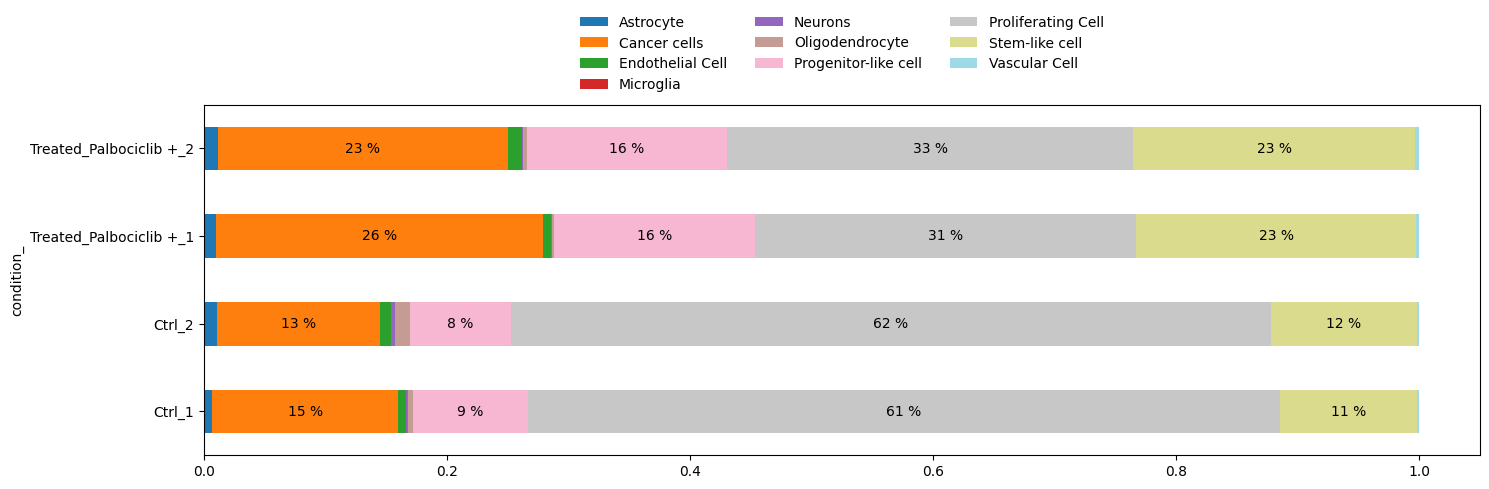

In [17]:
fig,ax = plt.subplots(figsize=(15, 5))
x_var, y_var = "condition_", "cell_type"
df_grouped = df_c_drug_all.groupby(x_var)[y_var].value_counts(normalize=True).unstack(y_var).fillna(0)

df_grouped.plot.barh(stacked=True, ax=ax, cmap="tab20")
plt.legend(
    bbox_to_anchor=(0.5, 1.02),
    loc="lower center",
    borderaxespad=0,
    frameon=False,
    ncol=3,
)
for ix, row in df_grouped.reset_index(drop=True).iterrows():
    # print(ix, row)
    cumulative = 0
    for element in row:
        if element == element and element > 0.05:
            plt.text(
                cumulative + element / 2,
                ix,
                f"{int(element * 100)} %",
                va="center",
                ha="center",
            )
        cumulative += element
plt.tight_layout()
plt.savefig(CLS_PATH / "cell_type_drug_proportion_v3.pdf", dpi=300, bbox_inches="tight")